In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:

aaa = 'emg_data.csv'
df = pd.read_csv(aaa, dtype=str)
df['emg_value'] = pd.to_numeric(df['emg_value'], errors='coerce')

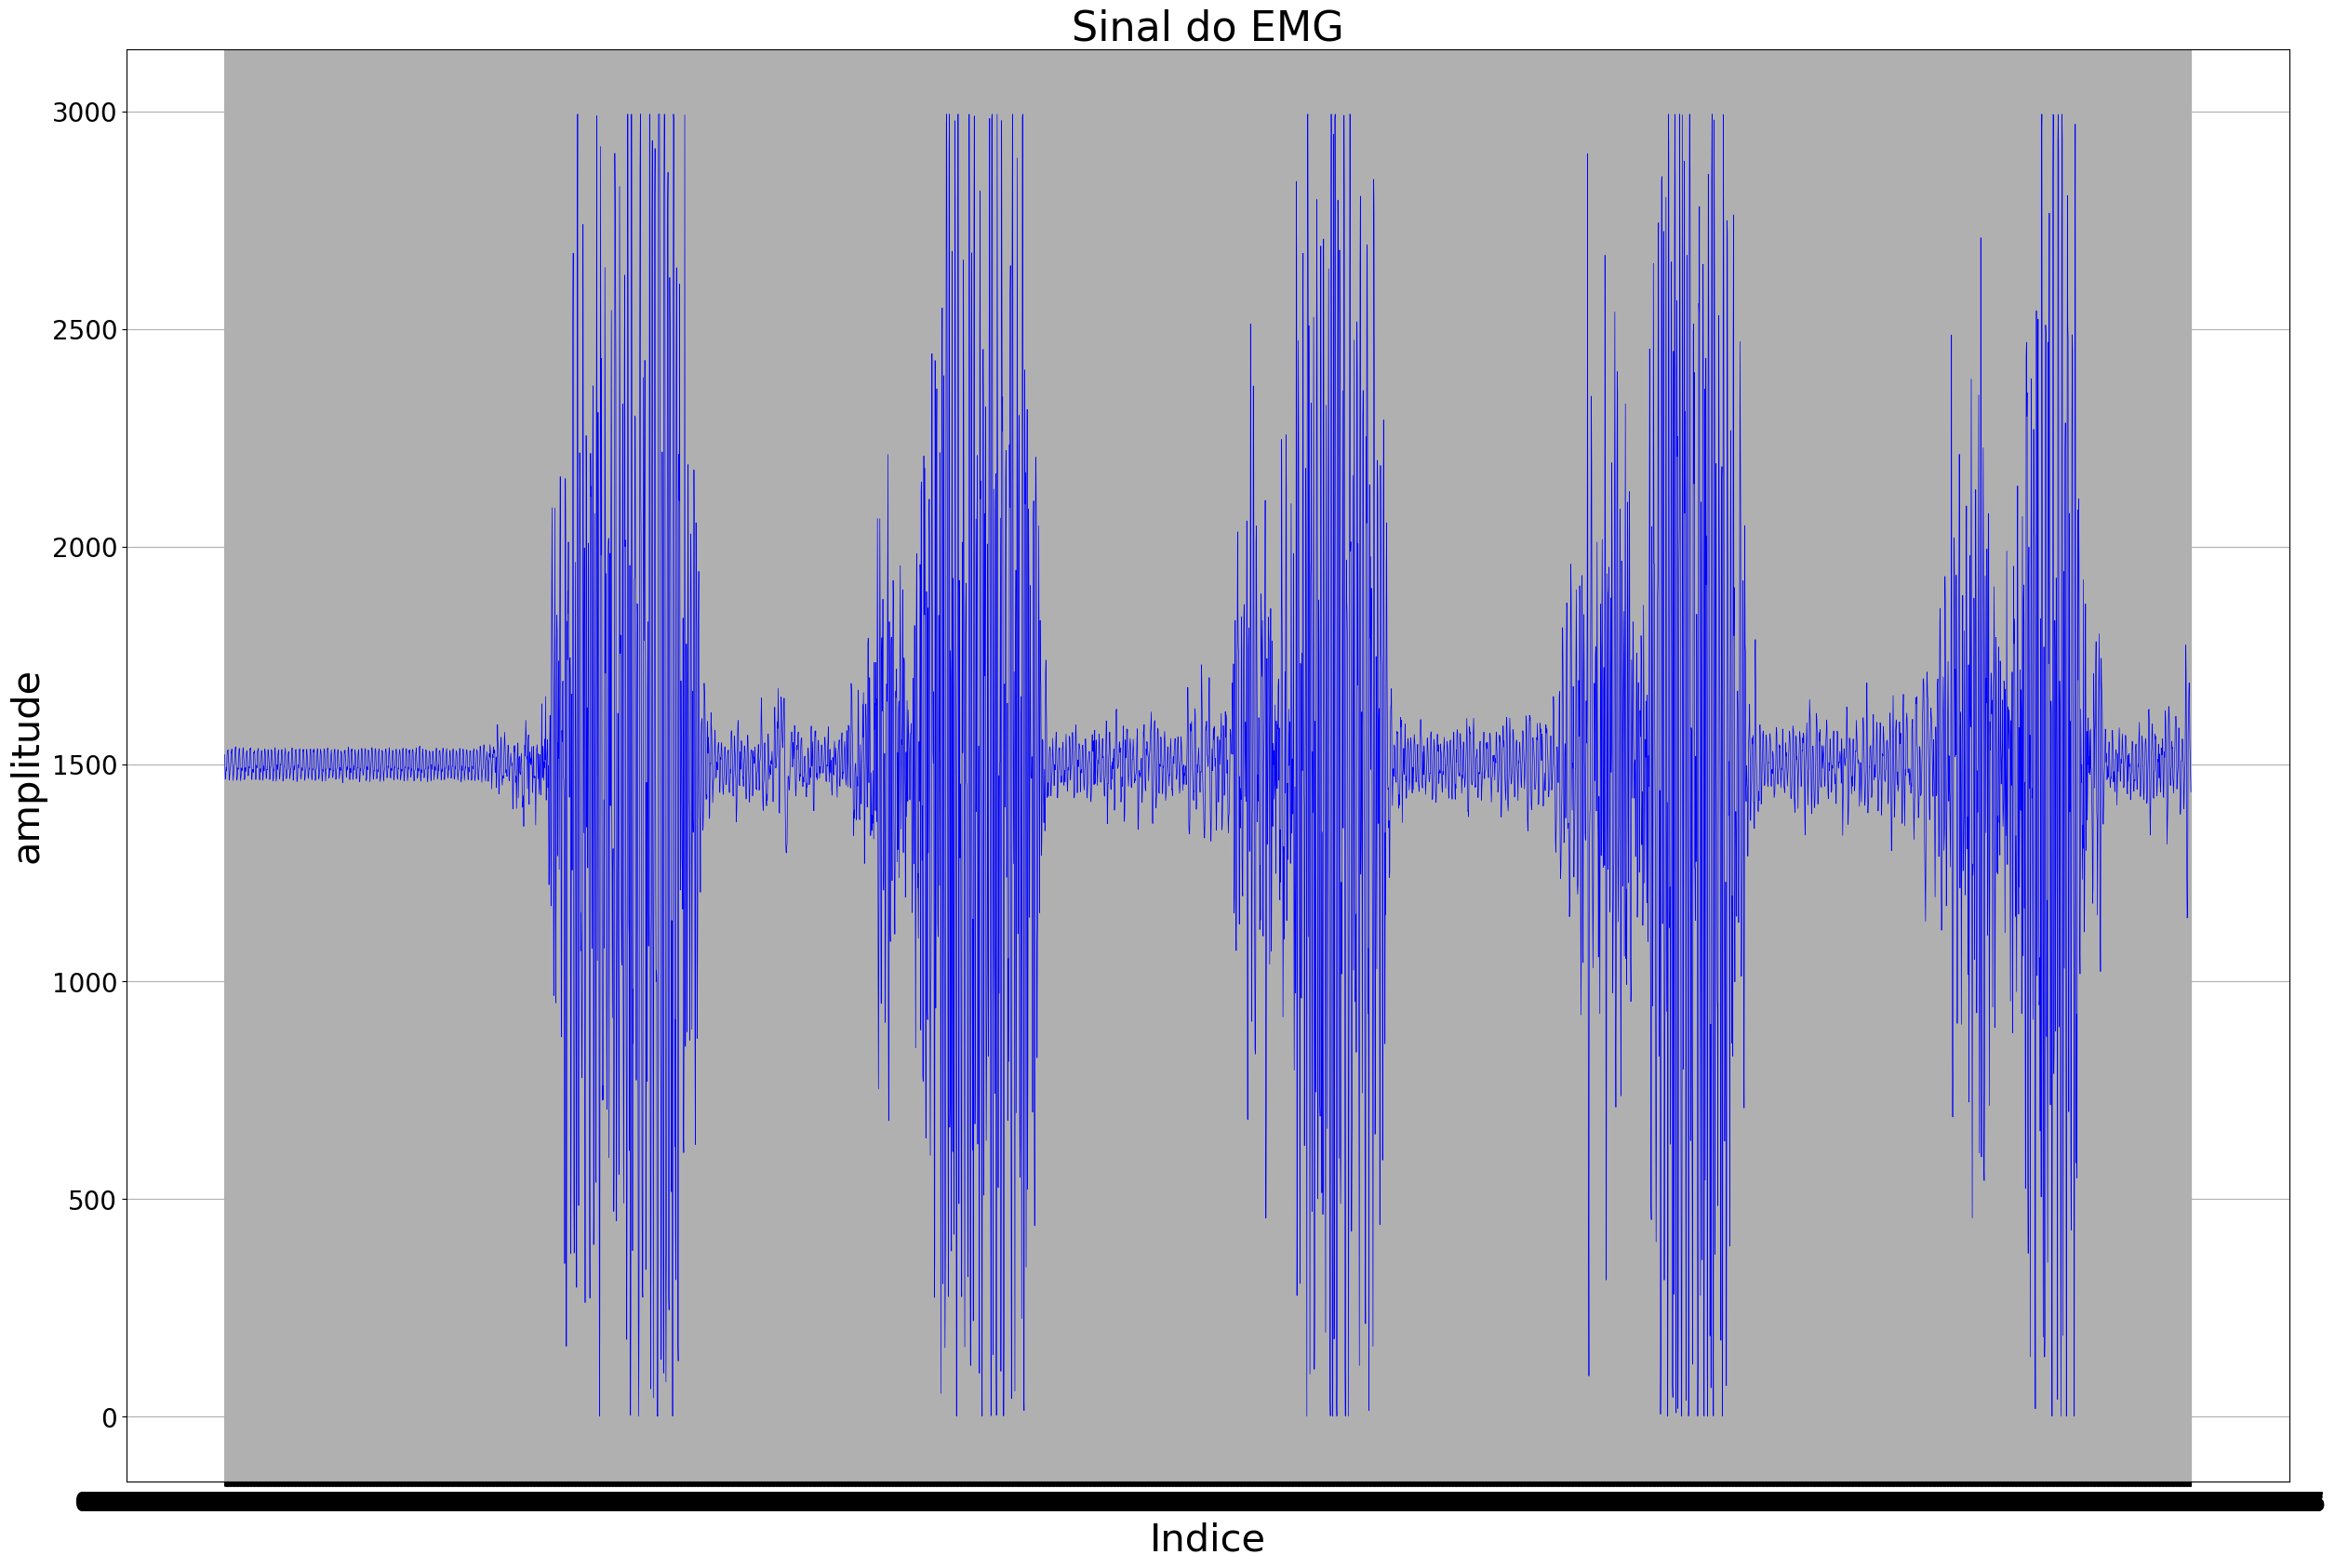

In [22]:
plt.figure(figsize=(30,20))
plt.plot(df['t (s)'], df['emg_value'], color='b', linewidth=0.5)
plt.title('Sinal do EMG', fontsize = 32)
plt.xlabel('Indice', fontsize = 30)
plt.ylabel('amplitude', fontsize = 30)
plt.grid(True)
plt.tick_params(axis='both', labelsize=20) 
plt.show()

#FILTROS

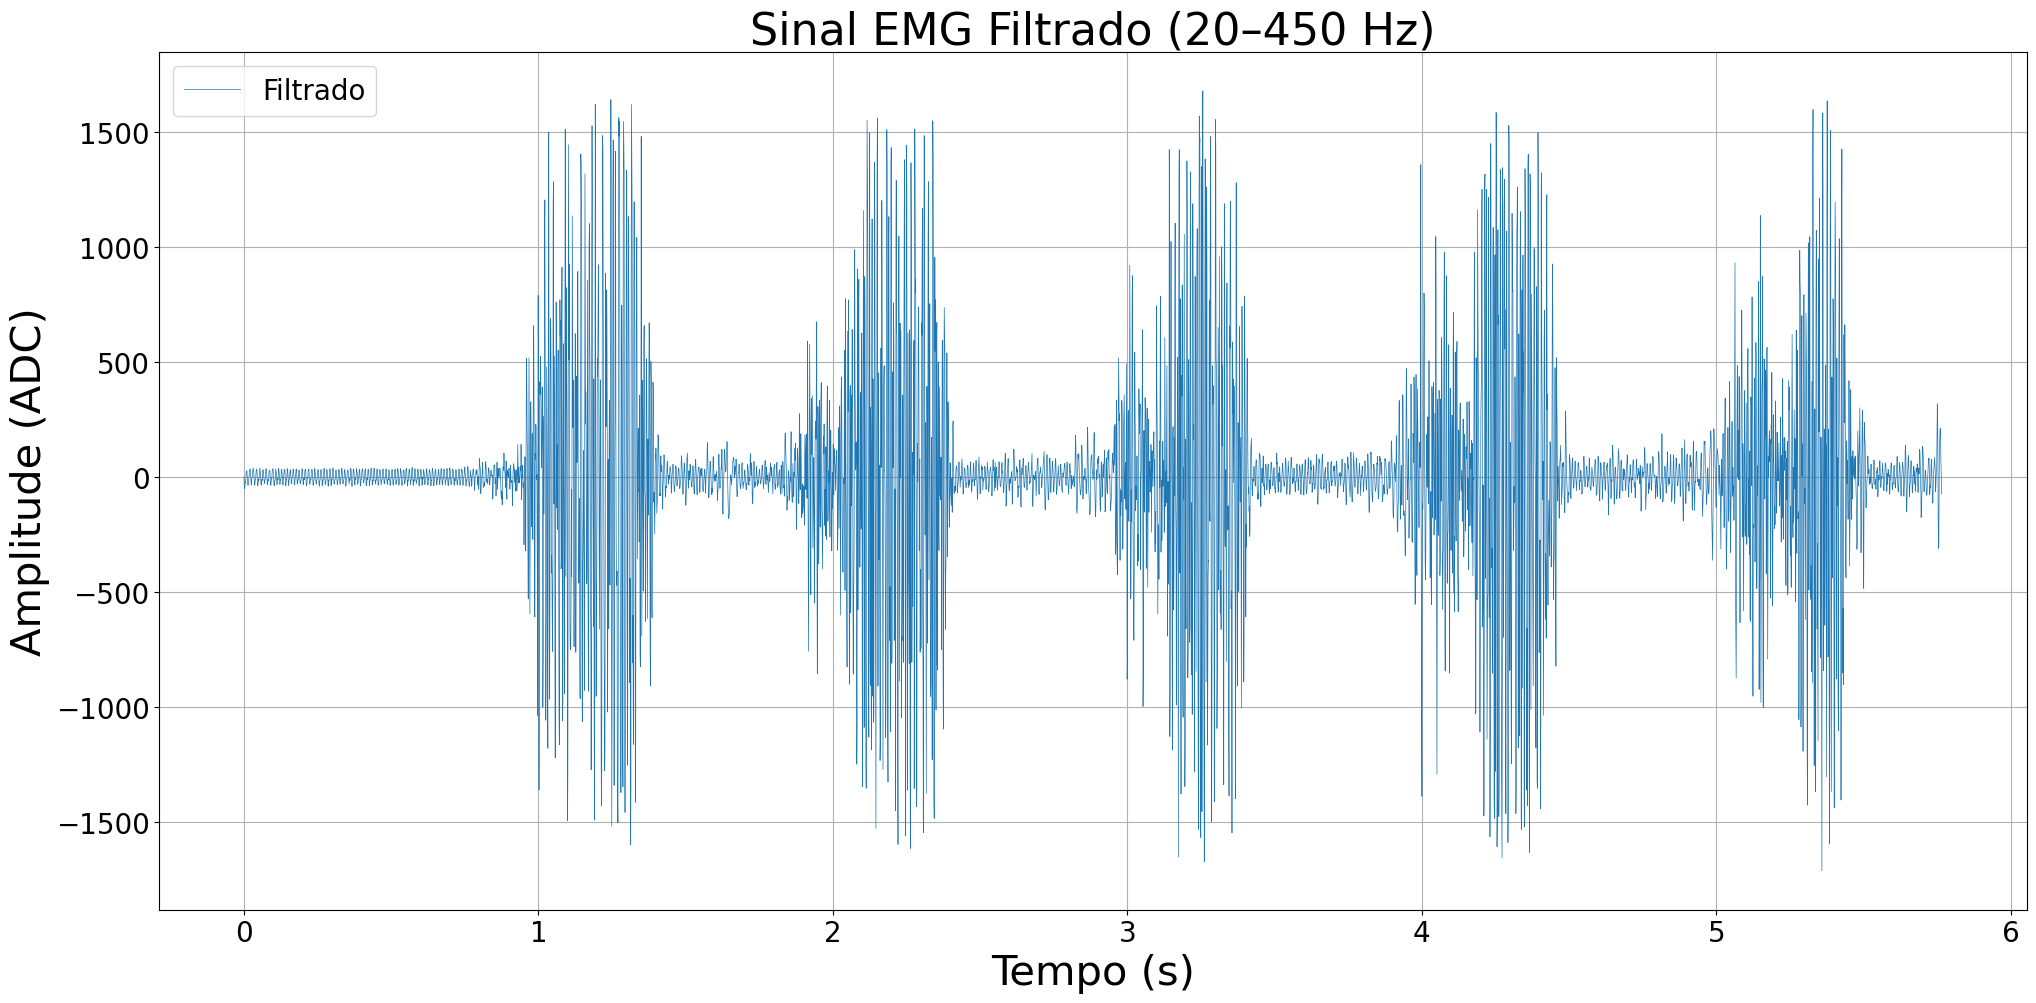

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- Funções de filtro ---
def filtro_passa_alta(dados, fs, fc, ordem=4):
    nyq = 0.5 * fs
    normal_fc = fc / nyq
    b, a = butter(ordem, normal_fc, btype='high')
    return filtfilt(b, a, dados)

def filtro_passa_baixa(dados, fs, fc, ordem=4):
    nyq = 0.5 * fs
    normal_fc = fc / nyq
    b, a = butter(ordem, normal_fc, btype='low')
    return filtfilt(b, a, dados)

def filtro_rejeita_banda(dados, fs, f1, f2, ordem=4):
    nyq = 0.5 * fs
    low = f1 / nyq
    high = f2 / nyq
    b, a = butter(ordem, [low, high], btype='bandstop')
    return filtfilt(b, a, dados)

# --- Parâmetros ---
arquivo = 'emg_data.csv'
fs = 1000  # Hz
ordem = 4

# Frequências de corte
fc_passa_alta = 20     # Hz
fc_passa_baixa = 450 # Hz
f_rejeita1 = 59        # faixa de rejeição em torno de 60Hz
f_rejeita2 = 61

# --- Leitura dos dados ---
df = pd.read_csv(arquivo)
dados = pd.to_numeric(df['emg_value'], errors='coerce').dropna().values

# --- Remoção do offset DC ---
dados = dados - np.mean(dados)

# --- Aplicação dos filtros ---
dados_filtrados = filtro_passa_alta(dados, fs, fc_passa_alta, ordem)
dados_filtrados = filtro_passa_baixa(dados_filtrados, fs, fc_passa_baixa, ordem)




# --- Tempo para gráfico ---
tempo = np.arange(len(dados)) / fs

# --- Gráfico ---
plt.figure(figsize=(20, 10))
plt.plot(tempo, dados_filtrados, label='Filtrado', linewidth=0.5)
plt.title('Sinal EMG Filtrado (20–450 Hz)', fontsize=32)
plt.xlabel('Tempo (s)', fontsize=30)
plt.ylabel('Amplitude (ADC)', fontsize=30)
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.tick_params(axis='both', labelsize=20) 
plt.show()


#FFT COM FILTRO

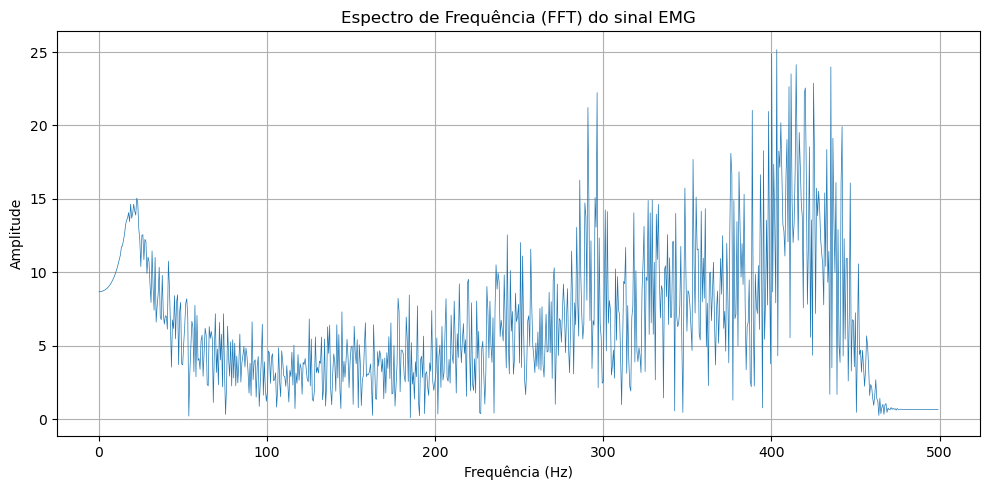

In [16]:
from scipy.fft import fft, fftfreq

# Configurações
arquivo_csv = 'dados_cvsAD.csv'
frequencia_amostragem = 1000  # Hz
# FFT
N = len(dados_filtrados)
T = 1.0 / frequencia_amostragem
yf = fft(dados_filtrados)
xf = fftfreq(N, T)[:N // 2]
amplitudes = 2.0 / N * np.abs(yf[:N // 2])

# Plot
plt.figure(figsize=(10, 5))
plt.plot(xf, amplitudes, linewidth=0.5)
plt.title('Espectro de Frequência (FFT) do sinal EMG')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
raise RuntimeError("Parando aqui de propósito!")
print(df['dado'].describe())

count    30695.000000
mean      1810.617918
std        771.262954
min          0.000000
25%       1485.000000
50%       1770.000000
75%       2101.000000
max       3919.000000
Name: dado, dtype: float64


In [ ]:
repetidos = df['dado'].value_counts().head(100)
print(repetidos)

dado
0       1011
3883     190
3881     186
3885     174
3887     151
        ... 
1759      50
1703      50
1687      49
1895      49
1591      49
Name: count, Length: 100, dtype: int64


**TKEO**

In [ ]:
def apply_tkeo(signal):
    """
    Aplica o operador TKEO a um sinal 1D.
    TKEO[x(n)] = x(n)^2 - x(n-1)*x(n+1)
    """
    tkeo = np.zeros_like(signal)
    # A fórmula só pode ser aplicada a partir do segundo até o penúltimo ponto
    tkeo[1:-1] = signal[1:-1]**2 - signal[:-2] * signal[2:]
    return tkeo

df['tkeo'] = apply_tkeo(dados_filtrados)

# Salva o resultado em um novo CSV
df.to_csv('dados_emg_com_tkeo.csv', index=False)



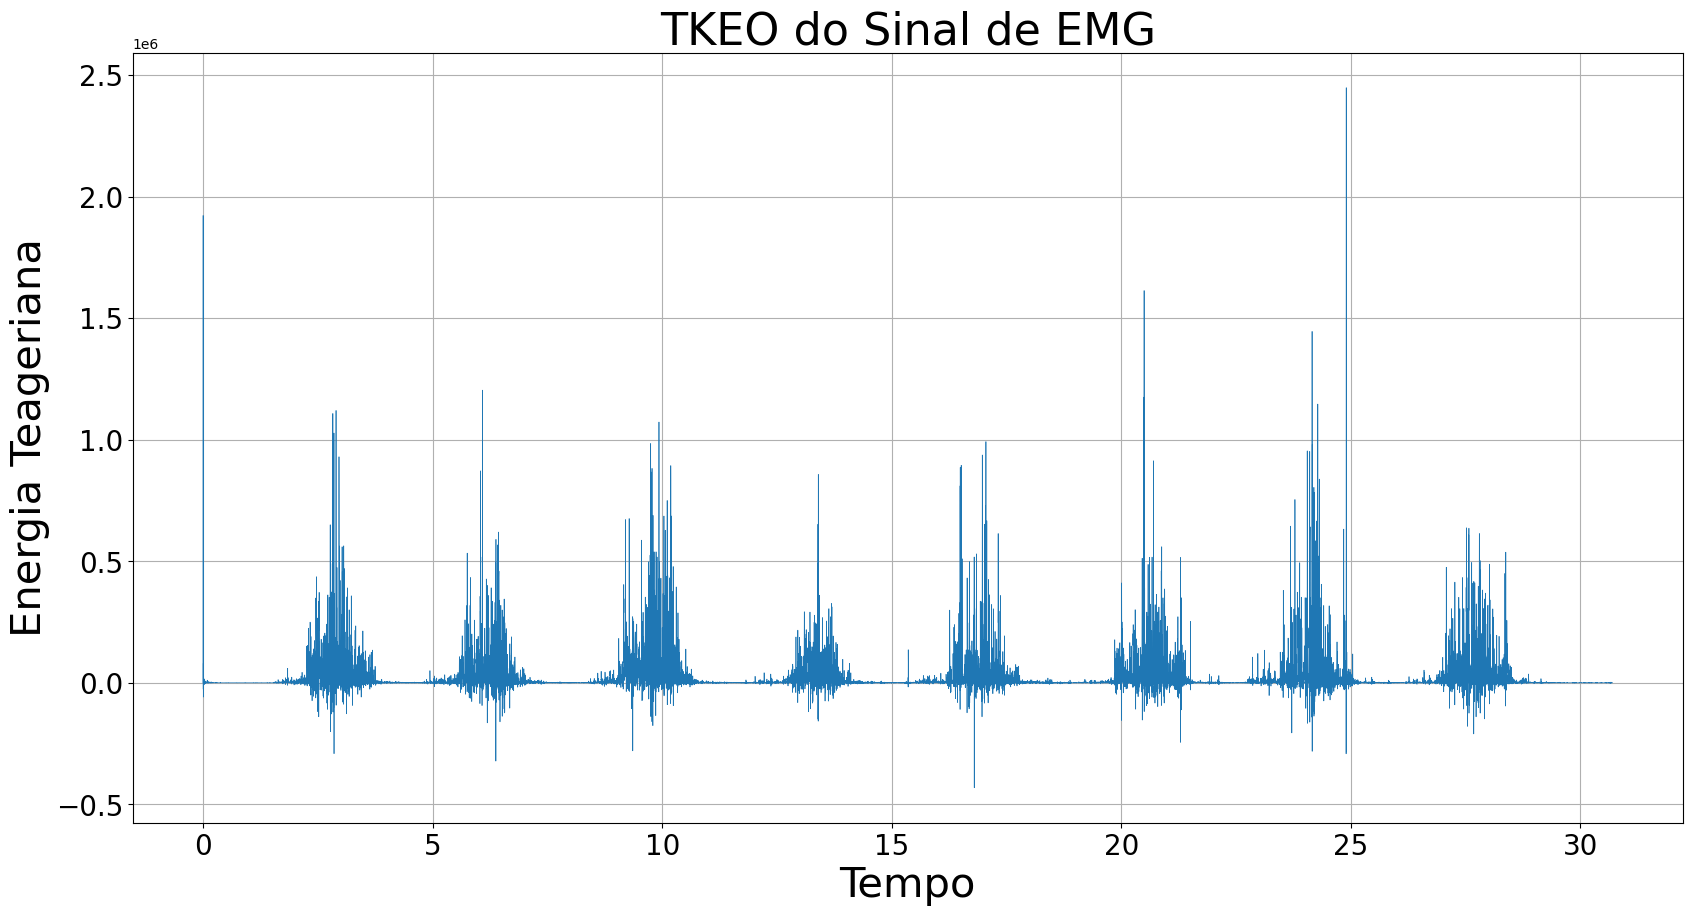

In [ ]:
tempo = np.arange(len(dados)) / fs

# --- Gráfico ---
plt.figure(figsize=(20, 10))
plt.plot(tempo, df['tkeo'], linewidth=0.5)
plt.title('TKEO do Sinal de EMG', fontsize=32)
plt.xlabel('Tempo', fontsize=30)
plt.ylabel('Energia Teageriana', fontsize=30)
plt.grid(True)
plt.tick_params(axis='both', labelsize=20) 
plt.show()

In [ ]:
#import pywt

In [ ]:
#signal = df['dado'].values

In [ ]:
#coeffs = pywt.wavedec(signal, 'db4', level=4)

In [ ]:
#scales = np.arange(1,512,1)
#coefficients, frequencies = pywt.cwt(signal, scales, 'morl')

In [ ]:
#plt.imshow(np.abs(coefficients), extent=[0, len(signal), 1, 512], cmap='PRGn', aspect='auto')
#plt.title('Transoformada wavelet continua')
#plt.show()

In [ ]:
#print(df['dado'].max())

ValueError: num must be 1 <= num <= 5, not 6

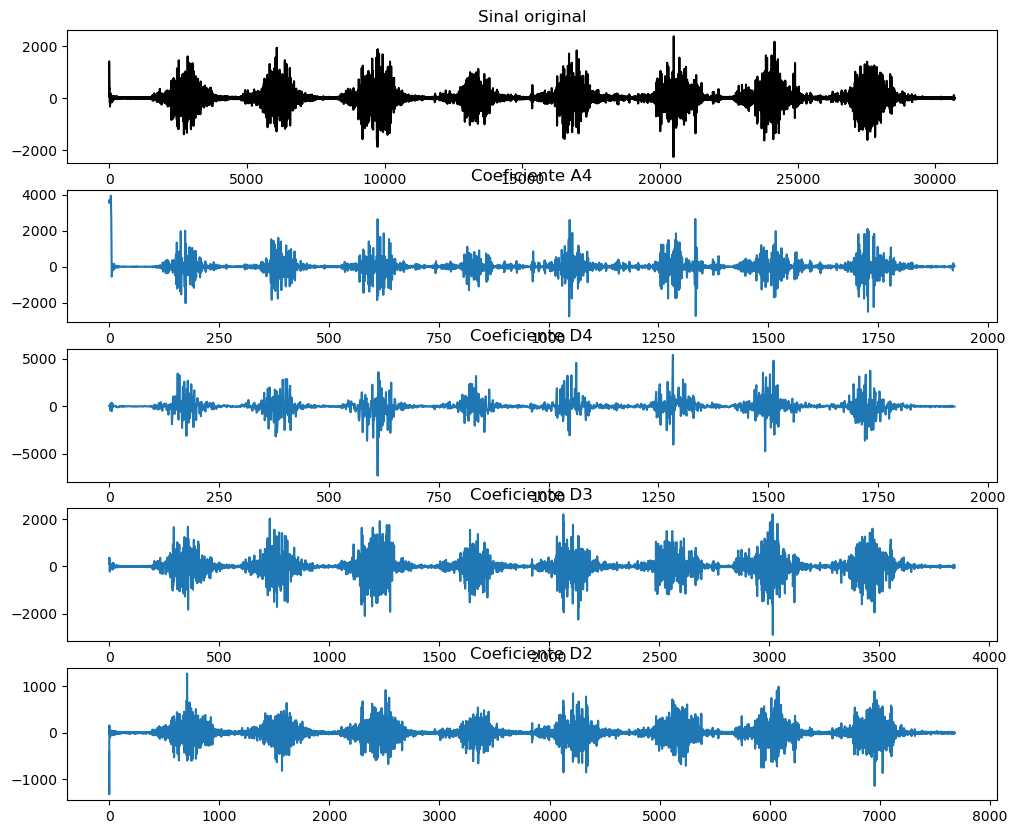

In [ ]:
import pywt
def aplicar_wavelet(signal, wavelet='db4', nivel=4, plotar=True):
    """
    Aplica a transformada discreta de wavelet (DWT) no sinal EMG.

    Parâmetros:
        signal: np.ndarray
            Sinal 1D (ex: EMG já pré-processado)
        wavelet: str
            Nome da wavelet (ex: 'db4', 'coif1', 'sym5')
        nivel: int
            Nível de decomposição (ex: 4)
        plotar: bool
            Se True, plota os coeficientes da decomposição

    Retorna:
        coeffs: lista
            Lista com os coeficientes [A_n, D_n, D_n-1, ..., D_1]
    """
    coeffs = pywt.wavedec(signal, wavelet, level=nivel)

    if plotar:
        plt.figure(figsize=(12, 2 * (nivel + 1)))
        plt.subplot(nivel+1, 1, 1)
        plt.plot(signal, color='black')
        plt.title('Sinal original')

        for i, coef in enumerate(coeffs):
            plt.subplot(nivel+1, 1, i+2)
            plt.plot(coef)
            label = 'A' + str(nivel) if i == 0 else 'D' + str(nivel - i + 1)
            plt.title(f'Coeficiente {label}')
        plt.tight_layout()
        plt.show()

    return coeffs

coeffs = aplicar_wavelet(dados_filtrados, wavelet='db4', nivel=4)

Apresenta claramente picos em 60HZ e 0Hz
O que diz: Há ruído de rede elétrica e de offset DC respectivamente
O ruído de 0Hz foi retirado utilizando um passa alta improvisado no script acima
Há frequências acima de 150Hz, que também normalmente representam ruídos, porém, visivelmente são muito inferiores ao ruído de rede elétrica

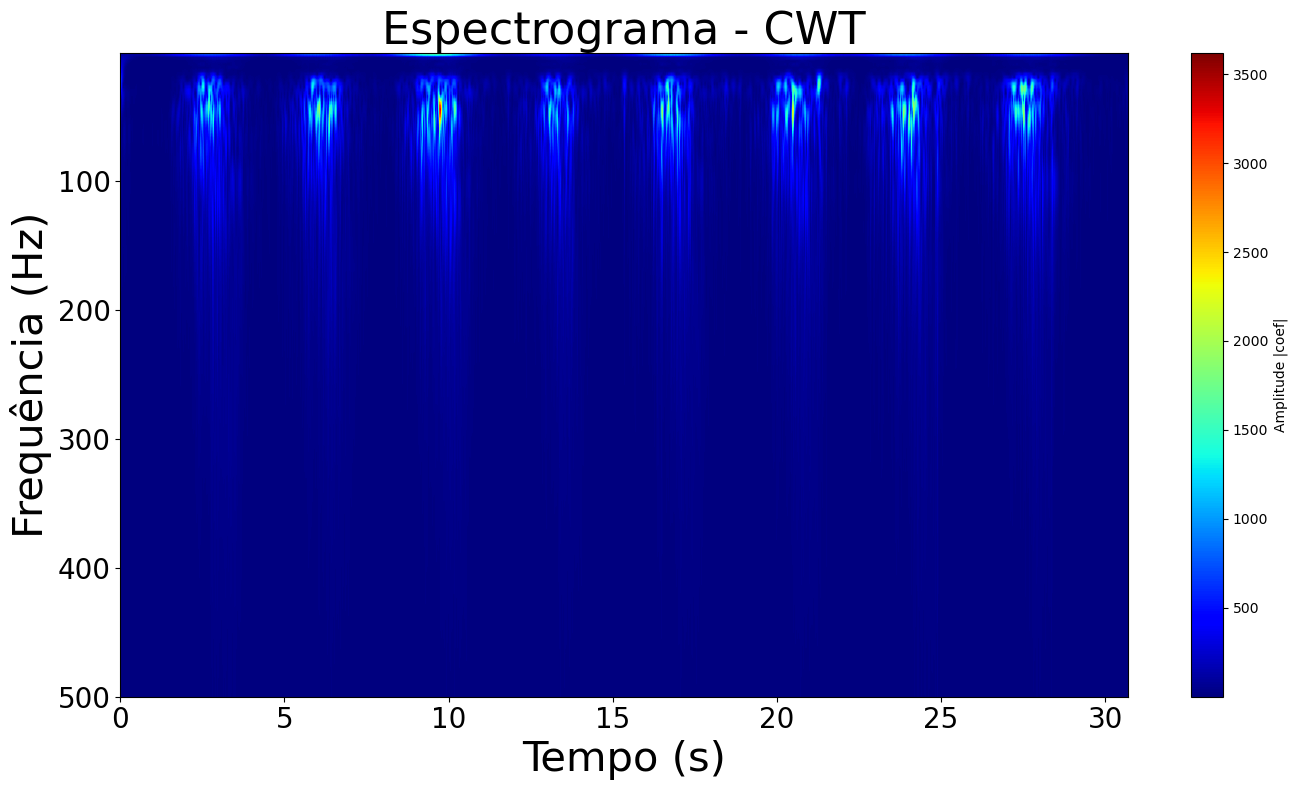

In [ ]:
def plotar_escalograma(signal, fs, wavelet='cmor1.5-1.0', escala_min=1, escala_max=128, num_escalas=64):
    """
    Plota o escalograma (CWT) de um sinal.
    
    Parâmetros:
        signal: array 1D
        fs: frequência de amostragem
        wavelet: wavelet contínua (ex: 'cmor1.5-1.0', 'morl', etc.)
        escala_min: escala mínima (baixa frequência)
        escala_max: escala máxima (alta frequência)
        num_escalas: número de escalas entre min e max
    """
    frequencies = np.linspace(1, 500, 200)
    scales = pywt.central_frequency(wavelet) * fs/frequencies
    coef, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=1/fs)

    plt.figure(figsize=(14, 8))
    plt.imshow(np.abs(coef), extent=[0, len(signal)/fs, freqs[-1], freqs[0]],
               cmap='jet', aspect='auto')
    plt.colorbar(label='Amplitude |coef|')
    plt.ylabel('Frequência (Hz)', fontsize=30)
    plt.xlabel('Tempo (s)', fontsize=30)
    plt.title('Espectrograma - CWT', fontsize=32)
    plt.tick_params(axis='both', labelsize=20) 
    plt.tight_layout()
    plt.show()

plotar_escalograma(dados_filtrados, fs=1000, wavelet='cmor1.5-1.0')

In [ ]:
from scipy.stats import spearmanr

def correlacao_spearman(x, y, verbose=True):
    """
    Calcula a correlação de Spearman entre dois vetores.

    Parâmetros:
        x, y: arrays ou listas numéricas de mesmo tamanho
        verbose: se True, imprime o resultado

    Retorna:
        coef: coeficiente de Spearman (entre -1 e 1)
        p_valor: significância estatística (quanto menor, mais confiável)
    """
    coef, p_valor = spearmanr(x, y)
    if verbose:
        print(f"Coeficiente de Spearman: {coef:.4f}")
        print(f"P-valor: {p_valor:.4e}")
        if p_valor < 0.05:
            print("Correlação estatisticamente significativa.")
        else:
            print("Correlação não significativa.")
    return coef, p_valor

correlacao_spearman(dados, dados_filtrados)

Coeficiente de Spearman: 0.3334
P-valor: 0.0000e+00
Correlação estatisticamente significativa.


(0.33338187028905353, 0.0)

ValueError: x and y must have same first dimension, but have shapes (15347,) and (30695,)

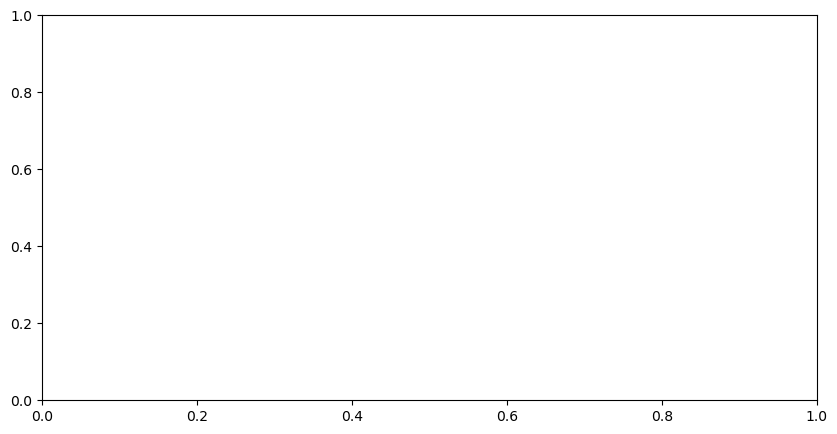

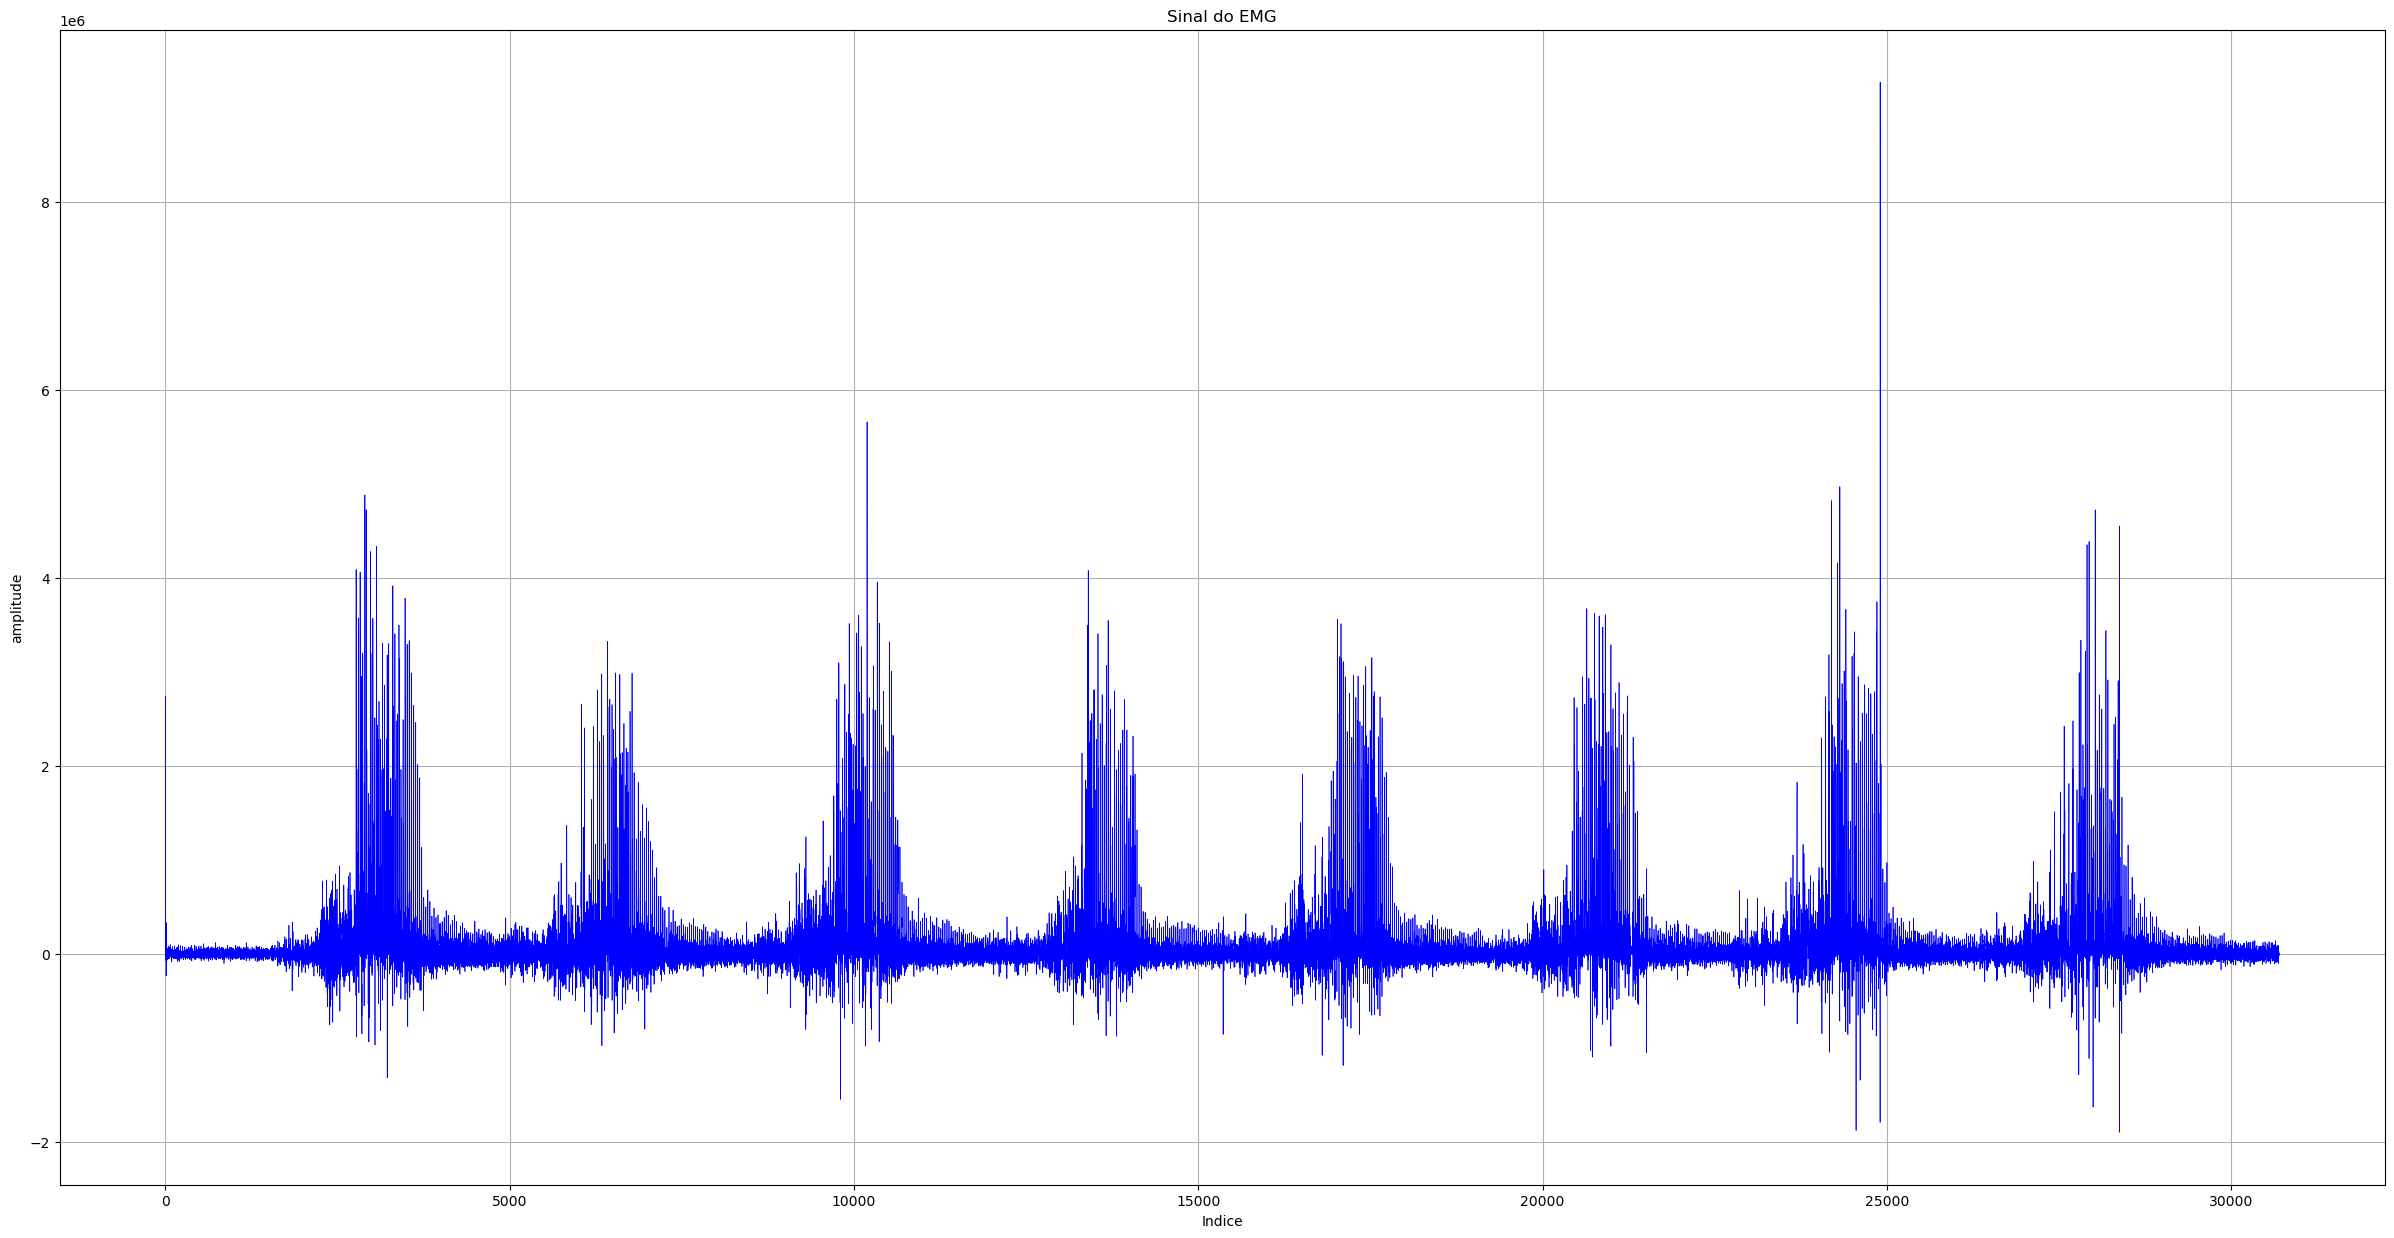

In [ ]:
def apply_tkeo(signal):
    """
    Aplica o operador TKEO a um sinal 1D.
    TKEO[x(n)] = x(n)^2 - x(n-1)*x(n+1)
    """
    tkeo = np.zeros_like(signal)
    # A fórmula só pode ser aplicada a partir do segundo até o penúltimo ponto
    tkeo[1:-1] = signal[1:-1]**2 - signal[:-2] * signal[2:]
    return tkeo

df['tkeo'] = apply_tkeo(df['dado'].values)

# Salva o resultado em um novo CSV
df.to_csv('dados_emg_com_tkeo.csv', index=False)

plt.figure(figsize=(30,15))
plt.plot(df['indice'], df['tkeo'], color='b', linewidth=0.5)
plt.title('Sinal do EMG')
plt.xlabel('Indice')
plt.ylabel('amplitude')
plt.grid(True)
plt.show()